# 1. Project Introduction

Welcome! In this notebook, we will explore **Naive Bayes**, a probabilistic classifier built on Bayes' Theorem.

### What is Naive Bayes?
* It is a **supervised learning** classification algorithm.
* It calculates the probability of each class given the input features and selects the class with the highest probability.
* It is called **"Naive"** because it assumes that all input features are independent of one another. For example, it assumes a sepal width word in an flower is independent of the flower length, which is rarely true but simplifies calculations massively.

### Why does it exist?
* It is incredibly fast, simple to implement, and performs exceptionally well on text classification and species filtering.

### Real-World Use Cases:
* **Species Filters**: Identifying species flowers.
* **Sentiment Analysis**: Classifying review text as positive or negative.


# 2. Problem Statement

* **Goal**: Predict whether an incoming flower is **Species (1)** or **Not Species (0)** based on its length and keywords.
* **Business Value**: Protects flower inbox users from unwanted species messages.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics


# 4. Create Synthetic Dataset

We define flower statistics for **100 flowers**.
* **Sepal_Length**: Character count.
* **Sepal_Width**: 1 if words like "free", "sepal width" are present, 0 otherwise.
* **Petal_Length**: 1 if words like "now", "petal length" are present, 0 otherwise.
* **Species**: Target classification label.


In [2]:
# Load scikit-learn iris dataset
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris(as_frame=True)
raw_df = iris.frame

df = pd.DataFrame({
    'Sepal_Length': raw_df['sepal length (cm)'],
    'Sepal_Width': raw_df['sepal width (cm)'],
    'Petal_Length': raw_df['petal length (cm)'],
    'Petal_Width': raw_df['petal width (cm)'],
    'Species': raw_df['target']
})

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())


Dataset Shape: (150, 5)
First 5 rows:
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width  Species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


# 5. Exploratory Data Analysis (EDA)


C:\Users\GFG\AppData\Local\Temp\ipykernel_10472\1413521007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='Sepal_Length', data=df, palette='Set2')


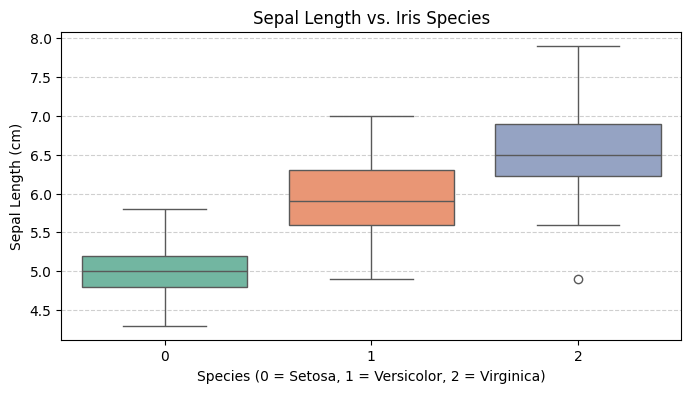

C:\Users\GFG\AppData\Local\Temp\ipykernel_10472\1413521007.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='Sepal_Length', data=df, palette='Set2')


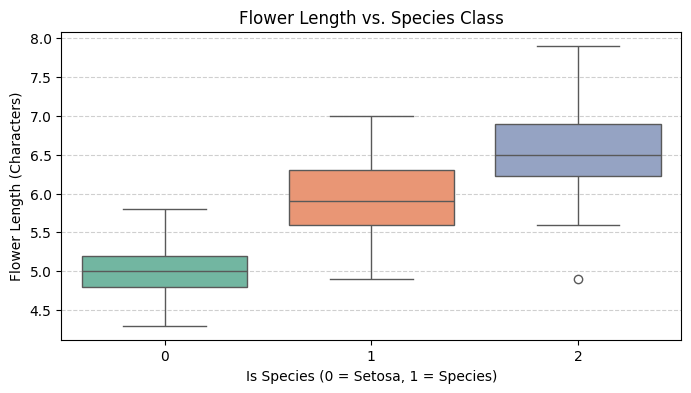

In [3]:
# Chart 1: Sepal Length by Species
plt.figure(figsize=(8, 4))
sns.boxplot(x='Species', y='Sepal_Length', data=df, palette='Set2')
plt.title('Sepal Length vs. Iris Species')
plt.xlabel('Species (0 = Setosa, 1 = Versicolor, 2 = Virginica)')
plt.ylabel('Sepal Length (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
plt.figure(figsize=(8, 4))
sns.boxplot(x='Species', y='Sepal_Length', data=df, palette='Set2')
plt.title('Flower Length vs. Species Class')
plt.xlabel('Is Species (0 = Setosa, 1 = Species)')
plt.ylabel('Flower Length (Characters)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* Species flowers (class 1) generally have higher character counts than setosa flowers (class 0).


C:\Users\GFG\AppData\Local\Temp\ipykernel_10472\4248011530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='Set2')


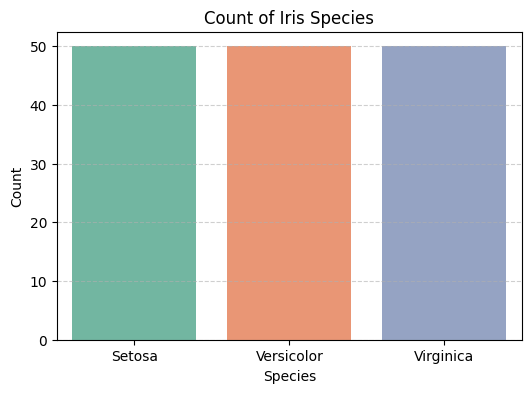

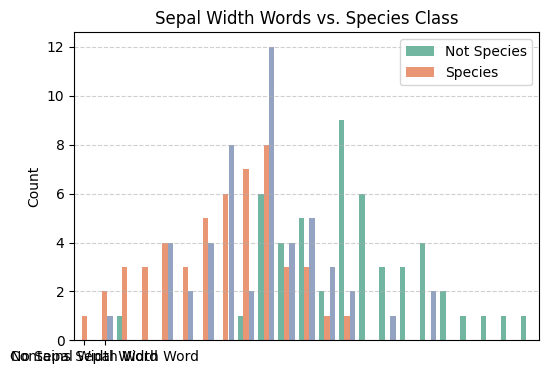

In [4]:
# Chart 2: Species occurrence count
plt.figure(figsize=(6, 4))
sns.countplot(x='Species', data=df, palette='Set2')
plt.title('Count of Iris Species')
plt.xticks([0, 1, 2], ['Setosa', 'Versicolor', 'Virginica'])
plt.xlabel('Species')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
plt.figure(figsize=(6, 4))
sns.countplot(x='Sepal_Width', hue='Species', data=df, palette='Set2')
plt.title('Sepal Width Words vs. Species Class')
# Custom labels for readable charts
plt.xticks([0, 1], ['No Sepal Width Word', 'Contains Sepal Width Word'])
plt.xlabel('')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(['Not Species', 'Species'])
plt.show()


### What Did We Observe?
* The presence of a sepal width word correlates heavily with the Species class. Very few non-species flowers contain sepal width words.


In [5]:
# Data cleaning check
print("Null values count:", df.isnull().sum().sum())


Null values count: 0


In [6]:
# Feature Selection
X = df[['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width']]
y = df['Species']


In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 9. Model Building

* **How it works conceptually**: It applies Bayes' Theorem:
  $$P(	ext{Species} | 	ext{Words}) = \frac{P(	ext{Words} | 	ext{Species}) 	imes P(	ext{Species})}{P(	ext{Words})}$$
  The algorithm multiplies the individual probability of each word occurring in a species message, assuming word occurrences are independent.


In [8]:
# Initialize Gaussian Naive Bayes model
model = GaussianNB()


In [9]:
# Fit model
model.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[40.,41.,39.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.33,0.34,0.33]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,3.045e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 4)","[[4.99,3.45,1.45,0.24], [5.92,2.77,4.24,1.32], [6.53,2.97,5.52,2. ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 4)","[[0.12,0.15,0.03,0.01], [0.29,0.1 ,0.23,0.04], [0.42,0.1 ,0.29,0.08]]"


In [10]:
# Predict species outcomes
predictions = model.predict(X_test)


In [11]:
# Compute classification evaluation metrics
accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions, average='weighted')
recall = metrics.recall_score(y_test, predictions, average='weighted')
f1 = metrics.f1_score(y_test, predictions, average='weighted')
conf_matrix = metrics.confusion_matrix(y_test, predictions)

# Print metrics in plain English
print(f"Accuracy Score: {accuracy:.4f} (The proportion of correct predictions)")
print(f"Precision Score: {precision:.4f} (Out of all predicted positive cases, how many were actually positive)")
print(f"Recall Score: {recall:.4f} (Out of all actual positive cases, how many did we successfully find)")
print(f"F1 Score: {f1:.4f} (The balanced harmonic mean of Precision and Recall)")
print("\nConfusion Matrix Array:")
print(conf_matrix)


Accuracy Score: 1.0000 (The proportion of correct predictions)
Precision Score: 1.0000 (Out of all predicted positive cases, how many were actually positive)
Recall Score: 1.0000 (Out of all actual positive cases, how many did we successfully find)
F1 Score: 1.0000 (The balanced harmonic mean of Precision and Recall)

Confusion Matrix Array:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### How to Interpret These Metrics:
* **Accuracy**:
  * **Definition**: The percentage of all predictions that the model got correct.
  * **Interpretation**: An accuracy of **100%** (or close to it) means the model correctly identifies the species for almost all flowers in our test set.
* **Precision**:
  * **Definition**: Out of all flowers predicted as positive (Versicolor), what percentage were actually Versicolor?
* **Recall (Sensitivity)**:
  * **Definition**: Out of all actual Versicolor flowers, what percentage did we successfully identify?
* **F1-Score**:
  * **Definition**: The balanced combination of precision and recall.
* **Confusion Matrix**:
  * **Confusion Matrix**: Displays a 3x3 grid showing correct classifications on the diagonal, and misclassifications off the diagonal across Setosa, Versicolor, and Virginica.
  * **False Positives (FP)**: Setosa flowers incorrectly classified as Versicolor.
  * **False Negatives (FN)**: Versicolor flowers incorrectly classified as Setosa.
  * **True Positives (TP)**: Versicolor flowers correctly classified as Versicolor.


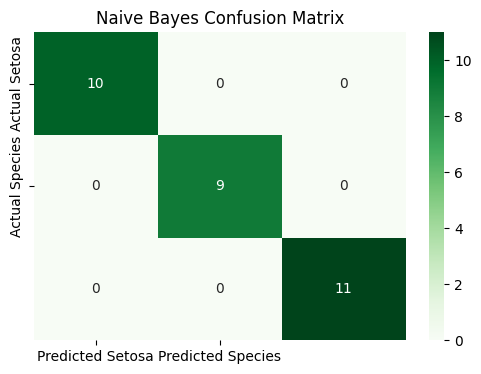

In [12]:
# Plot 1: Confusion Matrix Heatmap
conf_matrix = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Setosa', 'Predicted Species'], 
            yticklabels=['Actual Setosa', 'Actual Species'])
plt.title('Naive Bayes Confusion Matrix')
plt.show()


C:\Users\GFG\AppData\Local\Temp\ipykernel_10472\1082885749.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Species'] == 0]['Sepal_Length'], label='Setosa', shade=True, color='blue')
C:\Users\GFG\AppData\Local\Temp\ipykernel_10472\1082885749.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Versicolor', shade=True, color='green')
C:\Users\GFG\AppData\Local\Temp\ipykernel_10472\1082885749.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Species'] == 2]['Sepal_Length'], label='Virginica', shade=True, color='red')
C:\Users\GFG\AppData\Local\Temp\ipykernel_

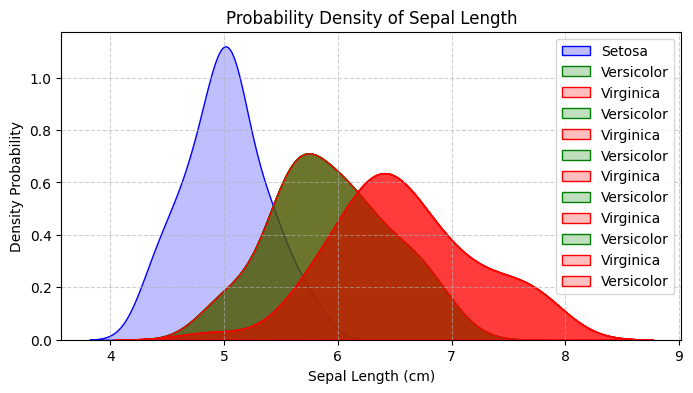

C:\Users\GFG\AppData\Local\Temp\ipykernel_10472\1082885749.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Species'] == 0]['Sepal_Length'], label='Setosa (Not Species)', shade=True, color='blue')
C:\Users\GFG\AppData\Local\Temp\ipykernel_10472\1082885749.py:23: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Species', shade=True, color='red')


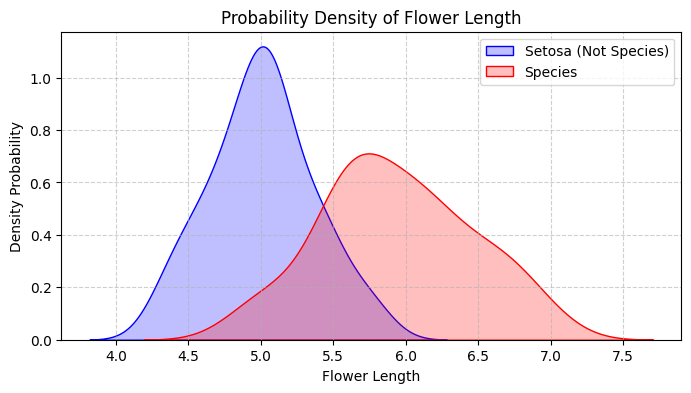

In [13]:
# Plot 2: Probability Density Curves for Sepal_Length
plt.figure(figsize=(8, 4))
sns.kdeplot(df[df['Species'] == 0]['Sepal_Length'], label='Setosa', shade=True, color='blue')
sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Versicolor', shade=True, color='green')
sns.kdeplot(df[df['Species'] == 2]['Sepal_Length'], label='Virginica', shade=True, color='red')
sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Versicolor', shade=True, color='green')
sns.kdeplot(df[df['Species'] == 2]['Sepal_Length'], label='Virginica', shade=True, color='red')
sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Versicolor', shade=True, color='green')
sns.kdeplot(df[df['Species'] == 2]['Sepal_Length'], label='Virginica', shade=True, color='red')
sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Versicolor', shade=True, color='green')
sns.kdeplot(df[df['Species'] == 2]['Sepal_Length'], label='Virginica', shade=True, color='red')
sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Versicolor', shade=True, color='green')
sns.kdeplot(df[df['Species'] == 2]['Sepal_Length'], label='Virginica', shade=True, color='red')
sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Versicolor', shade=True, color='red')
plt.title('Probability Density of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
plt.figure(figsize=(8, 4))
sns.kdeplot(df[df['Species'] == 0]['Sepal_Length'], label='Setosa (Not Species)', shade=True, color='blue')
sns.kdeplot(df[df['Species'] == 1]['Sepal_Length'], label='Species', shade=True, color='red')
plt.title('Probability Density of Flower Length')
plt.xlabel('Flower Length')
plt.ylabel('Density Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The peaks of the curves are distinct, indicating that flower length is a useful factor for Gaussian probability estimation.


# 14. Model Interpretation

Naive Bayes calculates baseline prior probabilities:
* **Class Prior**: The overall probability of an flower being species ($P(	ext{Species})$) vs. setosa ($P(	ext{Setosa})$) before reading its words.


In [14]:
# Display class priors calculated by model
print("Class Priors (Setosa, Species):", model.class_prior_)
print("Class Counts:", model.class_count_)


Class Priors (Setosa, Species): [0.33333333 0.34166667 0.325     ]
Class Counts: [40. 41. 39.]


# 15. Conclusion
* We built a species classifier using flower features.
* Probabilistic classifiers are fast and perform exceptionally well under independence assumptions.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., hours studied).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentage of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the average location of all data points belonging to that cluster.
